In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import h5py, glob, re, os, gc, pickle, scipy.sparse, time
from shapely.geometry import Point, Polygon
import shapely
import glob, gc
import geopandas as gpd

basedir = '/data/srlab/AMP_collab/data/early_disease_synovium/'
xeniumdir = f'{basedir}/xenium'

In [2]:
metadata = pd.read_csv(f'{basedir}/Xenium_RA-SYN-ARBITRATE_assay manifest.csv').set_index('Sample_ID')
metadata['subset'] = 'ARBITRATE'

In [3]:
def read(slide_id):
    print('reading', slide_id)
    slideinfo = metadata[metadata['Xenium-Slide_Sample_ID'] == slide_id]
    subset = slideinfo.subset.iloc[0]
    paths = glob.glob(f'{xeniumdir}/Xenium_RA-SYN-{subset}/Level_1_Xenium_Output/{slide_id}/*')
    samps = {}
    for path in paths: 
        transcripts = pd.read_parquet(f'{path}/transcripts.parquet', engine='fastparquet') 
        gene_transcripts = transcripts[(transcripts.is_gene) & (transcripts.qv >= 20)]
        samp = path.split("/")[-1].split('xenium_output_')[1]
        samps[samp] = gene_transcripts 
    return samps, subset, paths

# Define sample polygons for each slide

In [4]:
def visualize(tx, polygons, figw=5, interval=2500):
    ix = np.random.choice(len(tx), 50000, replace=False)
    plt.figure(figsize=(figw,figw))
    plt.scatter(tx.iloc[ix].x_location, tx.iloc[ix].y_location, s=1, alpha=0.3)
    for name, polygon in polygons.items():
        plt.plot(*np.array(polygon.exterior.coords).T)
        plt.text(polygon.centroid.x, polygon.centroid.y, name, ha='center', va='center', fontsize=12, color='red')
    plt.axis('equal')
    ax = plt.gca()
    ax.grid(True, which='major')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(interval))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(interval))
    plt.show()
    
def arrange_samples(tx, higher_sample_index, polygons=True): 
    order = {0: 'pre_treatment', 1: 'post_treatment'}
    higher_sample = next(samp for samp in tx.keys() if order[higher_sample_index] in samp) 
    lower_sample = next(samp for samp in tx.keys() if order[higher_sample_index] not in samp)
    tx[higher_sample].y_location += tx[lower_sample].y_location.max() + 1000 
    if not polygons: 
        return(pd.concat(tx.values())) 
    
    polygons = {}
    for name, df in tx.items():
        xmin = (df.x_location.min() // 1000) * 1000
        xmax = ((df.x_location.max() // 1000) + 1) * 1000
        ymin = (df.y_location.min() // 1000) * 1000
        ymax = ((df.y_location.max() // 1000) + 1) * 1000

        polygons[name] = Polygon([
            (xmin, ymin),
            (xmin, ymax),
            (xmax, ymax),
            (xmax, ymin)
        ])
    tx = pd.concat(tx.values())
    return(tx, polygons) 
    

def annotate(slide_id, higher_sample_index, save=True, figw=5):
    tx, subset, path = read(slide_id)
    print(subset)
    for name in tx.keys():
        if metadata.loc[name, 'Xenium-Slide_Sample_ID'] != slide_id:
            print('ERROR: sample id doesnt match slide')
            print('got:', name)
            print('samples on slide are:', metadata[metadata['Xenium-Slide_Sample_ID'] == slide_id].index)
            return
    
    tx, polygons = arrange_samples(tx, higher_sample_index, polygons=True) 
    visualize(tx, polygons, figw=figw)

    if save:
        data = {
            'sampleID': list(polygons.keys()),
            'slideID' : [slide_id] * len(polygons)
        }
        gdf = gpd.GeoDataFrame(
            data,
            geometry=list(polygons.values()),
            crs=None)
        gdf.attrs['name'] = f'xenium_bbox_synovium_{slide_id}'
        target = f'{xeniumdir}/Xenium_RA-SYN-{subset}/Level_2/'
        os.makedirs(target, exist_ok=True)
        gdf.to_file(f'{target}/xenium_bbox_synovium_{slide_id}.geojson', driver='GeoJSON')

    return tx

reading patient1
ARBITRATE


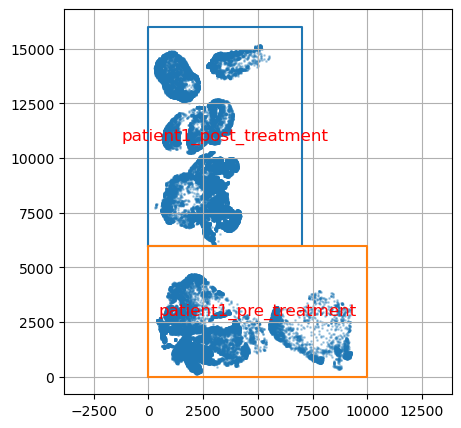

ERROR 1: PROJ: proj_create_from_database: Open of /data/srlab/lsood/miniforge3/envs/amp_yakir/share/proj failed
/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient10
ARBITRATE


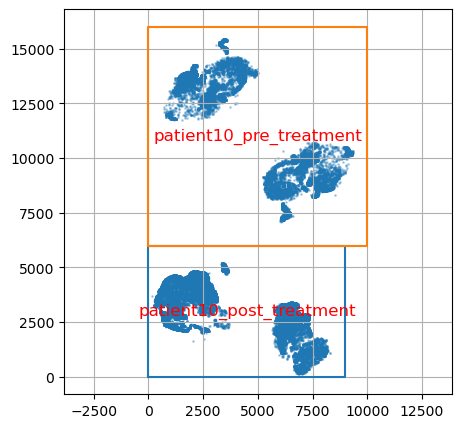

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient11
ARBITRATE


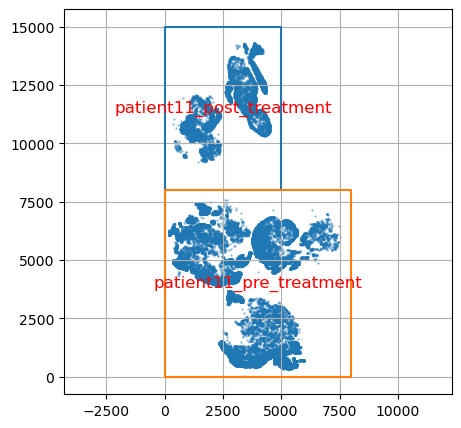

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient12
ARBITRATE


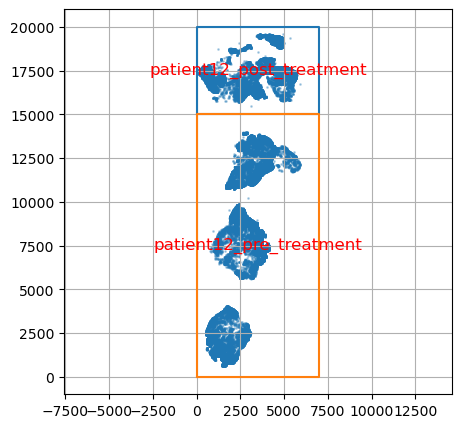

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient13
ARBITRATE


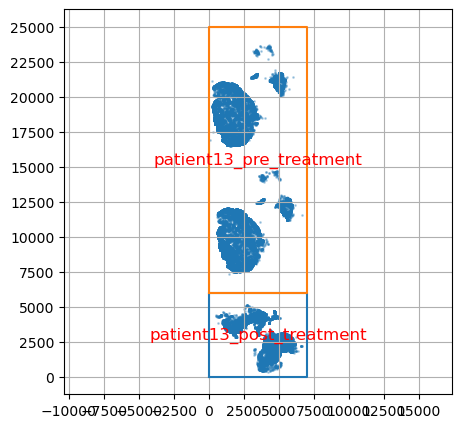

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient14
ARBITRATE


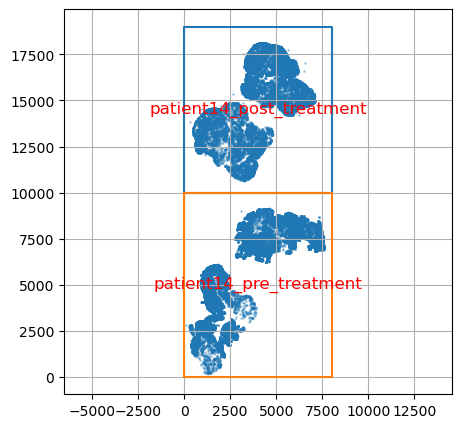

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient15
ARBITRATE


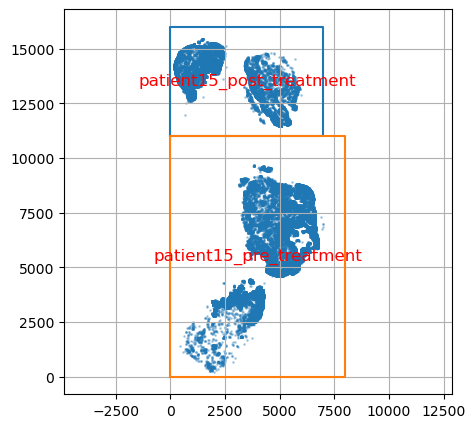

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient16
ARBITRATE


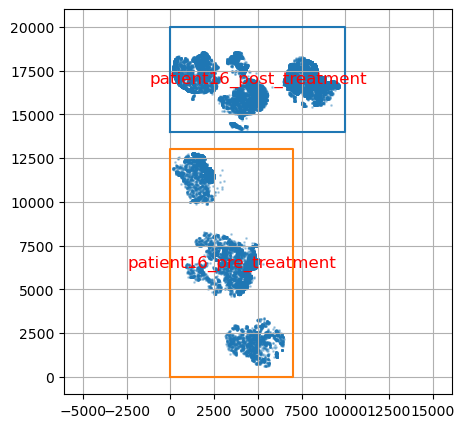

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient17
ARBITRATE


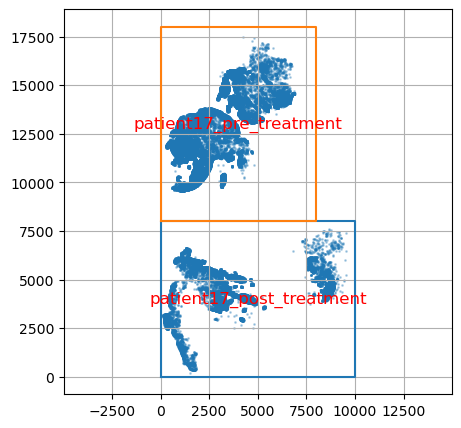

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient2
ARBITRATE


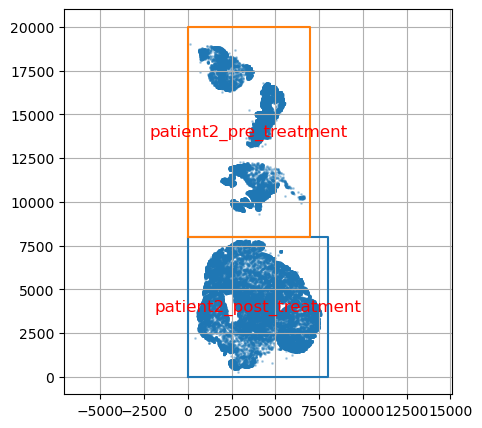

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient3
ARBITRATE


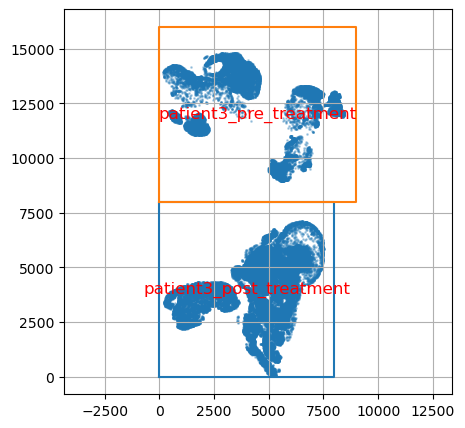

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient4
ARBITRATE


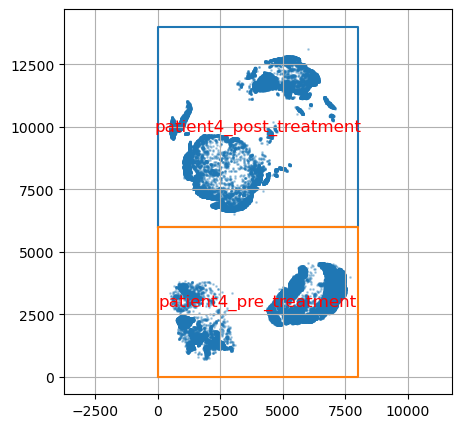

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient5
ARBITRATE


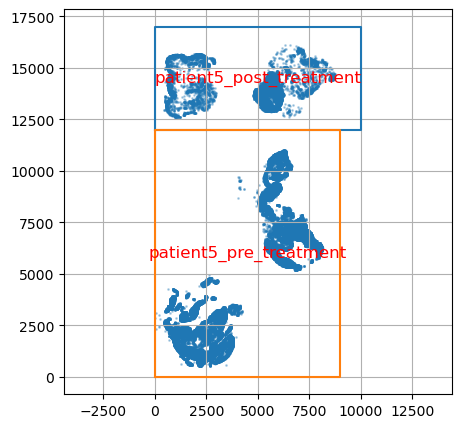

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient6
ARBITRATE


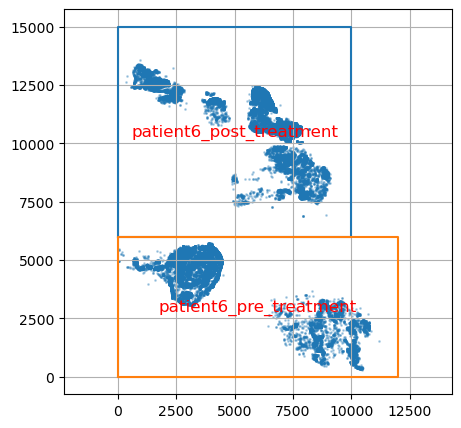

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient7
ARBITRATE


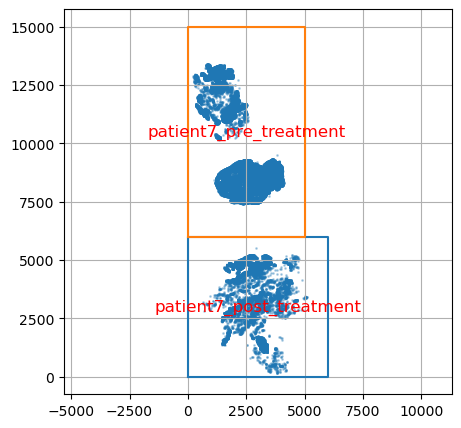

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient8
ARBITRATE


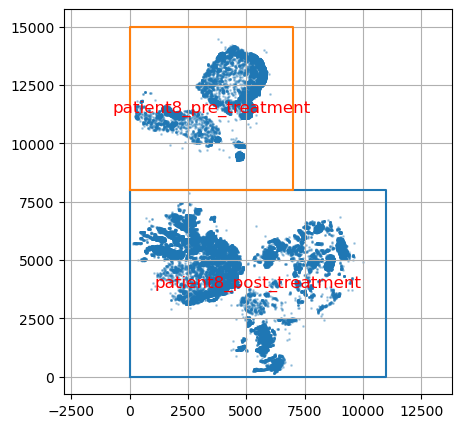

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


reading patient9
ARBITRATE


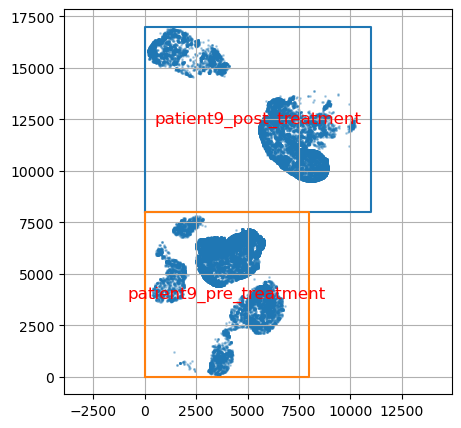

/data/srlab/lsood/miniforge3/envs/amp_yakir/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [7]:
rng = np.random.default_rng(seed=42) 
higher_sample_ordering = rng.binomial(p=0.5, n=1, size=len(metadata['Xenium-Slide_Sample_ID'].unique())) 

for i, subj_id in enumerate(metadata['Xenium-Slide_Sample_ID'].unique()): 
    tx = annotate(subj_id, higher_sample_index=higher_sample_ordering[i])

# Split into samples and QC transcripts and genes

## compute gene-level info, filter transcripts, and split samples

In [8]:
features = ['x_location', 'y_location', 'z_location', 'qv', 'nucleus_distance']

t0 = time.time()
os.makedirs('out/_gene_qc_metrics_ARBITRATEonly', exist_ok=True)
nslides = len(metadata['Xenium-Slide_Sample_ID'].unique())
for i, slide_id in enumerate(metadata['Xenium-Slide_Sample_ID'].unique()):
    print(f'slide {i+1} of {nslides}, time: {time.time() - t0:.2f}')
    tx, subset, path = read(slide_id)
    tx = arrange_samples(tx, higher_sample_index=higher_sample_ordering[i], polygons=False)
    print(subset)
    print(f'\t{len(tx)} transcripts')
    
    gene_info = tx[['feature_name']+features].groupby(by='feature_name').aggregate('mean')
    gene_info['ntranscripts'] = tx.feature_name.value_counts()
    gene_info['codeword_category'] = tx[['feature_name','codeword_category']].drop_duplicates().set_index('feature_name', drop=True).codeword_category
    gene_info['slide_id'] = slide_id
    gene_info.to_csv(f'out/_gene_qc_metrics_ARBITRATEonly/{slide_id}.csv')

    targetdir = f'out/samples'
    os.makedirs(targetdir, exist_ok=True)
    boundaries = gpd.read_file(f'{xeniumdir}/Xenium_RA-SYN-{subset}/Level_2/xenium_bbox_synovium_{slide_id}.geojson')
    for sid, poly in zip(boundaries.sampleID, boundaries.geometry):
        inside = shapely.contains_xy(poly, tx.x_location.values, tx.y_location.values)
        sample = tx[inside]
        print(f'\twriting {sid} ({len(sample)} transcripts)')
        outdir = f'{targetdir}/{sid}'
        if os.path.exists(outdir):
            print(f'\t!!! WAIT: {outdir} already exists! Did NOT overwrite.')
            #raise ValueError()
            continue
        os.makedirs(outdir, exist_ok=True)
        sample.to_parquet(f'{outdir}/transcripts_txqc.parquet')
        del sample; gc.collect()
    del tx; gc.collect()

slide 1 of 17, time: 0.00
reading patient1
ARBITRATE
	34205633 transcripts
	writing patient1_post_treatment (21137146 transcripts)
	writing patient1_pre_treatment (13068487 transcripts)
slide 2 of 17, time: 74.27
reading patient10
ARBITRATE
	21529658 transcripts
	writing patient10_post_treatment (13177423 transcripts)
	writing patient10_pre_treatment (8352235 transcripts)
slide 3 of 17, time: 125.39
reading patient11
ARBITRATE
	31345612 transcripts
	writing patient11_post_treatment (6146751 transcripts)
	writing patient11_pre_treatment (25198861 transcripts)
slide 4 of 17, time: 177.52
reading patient12
ARBITRATE
	28658897 transcripts
	writing patient12_post_treatment (9489369 transcripts)
	writing patient12_pre_treatment (19169528 transcripts)
slide 5 of 17, time: 225.91
reading patient13
ARBITRATE
	27311751 transcripts
	writing patient13_post_treatment (8699048 transcripts)
	writing patient13_pre_treatment (18612703 transcripts)
slide 6 of 17, time: 273.08
reading patient14
ARBITRATE

In [9]:
gene_infos = pd.concat([pd.read_csv(f) for f in glob.glob(f'out/_gene_qc_metrics_ARBITRATEonly/*.csv')], ignore_index=True)
gene_infos.to_parquet('out/_gene_qc_metrics_ARBITRATEonly/all.parquet')